In [556]:
import pandas as pd

In [557]:
missingValues = ['','nan',"NAN"]
sales1 = pd.read_csv('sales_data_part1.csv',na_values = missingValues)
sales2 = pd.read_csv('sales_data_part2.csv',na_values = missingValues)
customers = pd.read_csv('customers.csv')
pd.set_option('display.max_columns', None)


In [558]:
sales = pd.concat([sales1, sales2], ignore_index=True)


In [559]:
sales.columns = sales.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('-', '_')

In [560]:
text_cols = ['order_id','customer_id','product','product_code','sales_person','channel','country_code']
def standardize(x):
    return x.astype(str).str.strip().str.lower()

sales[text_cols] = sales[text_cols].apply(standardize)
sales.head()

,order_id,date,customer_id,country_code,channel,sales_person,units_sold,unit_price,product_code,product,promotion_flag,commission_percent
0,ord0000001,2022-01-14,custj00001,jo,online,ahmed,1,925.33,eb01,laptop,0,0.03
1,ord0000002,2021-12-21,custj00002,jo,offline,sara,5,161.18,eg02,gaming chair,0,0.05
2,ord0000003,2021-12-10,custj00002,jordan,offline,ahmed,3,4.94,e05,cable,0,0.05
3,ord0000004,2022-02-21,custj00002,jordn,website,ahmed,3,51.21,eg03,headset,0,0.02
4,ord0000005,2021-01-14,custj00002,jordn,website,rami,2,238.59,p02,tablet,0,0.05


In [561]:
sales.isna().sum()
(sales == '').sum()
(sales.apply(lambda col: col.astype(str).str.lower() == 'nan')).sum()


,0
order_id,0
date,0
customer_id,0
country_code,0
channel,5
sales_person,0
units_sold,0
unit_price,0
product_code,0
product,0


In [562]:
sales['channel'].unique()

array(['online', 'offline', 'website', 'in-store', 'nan'], dtype=object)

In [563]:
channel_map = {
    "online": "online",
    "website": "online",
    "offline": "offline",
    "in-store": "offline",
}

sales["channel"] = sales["channel"].map(channel_map)


In [564]:
sales['channel'].replace('nan','unknown', inplace =True)
sales['channel'].fillna('unknown', inplace=True)
sales['channel'].unique()

/tmp/ipython-input-799030796.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  sales['channel'].replace('nan','unknown', inplace =True)
/tmp/ipython-input-799030796.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', 

array(['online', 'offline', 'unknown'], dtype=object)

In [565]:
sales.duplicated().sum()

np.int64(15)

In [566]:
dupes_all = sales[sales.duplicated(keep=False)]
dupes_all

,order_id,date,customer_id,country_code,channel,sales_person,units_sold,unit_price,product_code,product,promotion_flag,commission_percent
711,ord0000664,2025-03-10,custj00089,jordan,offline,rami,3,6.24,e05,cable,0,0.05
1962,ord0001832,2023-05-11,custj00226,jordn,offline,ahmed,1,907.00,eb01,laptop,0,0.02
3443,ord0003191,2022-03-02,custj00407,jo,online,rami,3,47.69,eg03,headset,0,0.02
3574,ord0003316,2023-08-23,custj00410,jor,online,ali,1,162.98,m01,monitor,0,0.05
4239,ord0003927,2021-07-04,custj00486,jor,online,ahmed,5,31.44,e04,keyboard,0,0.05
4738,ord0004398,2021-10-21,custl00033,lebanon,online,sami,4,32.13,a01,accessory,0,0.03
7019,ord0006503,2024-06-11,custl00255,leb,online,lina,3,27.97,a01,accessory,0,0.03
7088,ord0006564,2022-08-18,custl00261,lebanon,online,lina,3,351.50,p02,tablet,0,0.03
8348,ord0007735,2023-06-26,custl00406,lebn,online,sami,1,27.08,a01,accessory,0,0.05
8462,ord0007841,2023-04-25,custl00421,lebn,online,lina,3,364.11,p02,tablet,0,0.05


In [567]:
dupes_all.to_csv('duplicates.csv', index=False)

In [568]:
sales = sales.drop_duplicates(keep='first').reset_index(drop=True)

In [569]:
sales.duplicated().sum()

np.int64(0)

In [570]:
sales.isna().sum()


,0
order_id,0
date,0
customer_id,0
country_code,0
channel,0
sales_person,0
units_sold,0
unit_price,0
product_code,0
product,0


In [571]:
(sales == '').sum()


,0
order_id,0
date,0
customer_id,0
country_code,0
channel,0
sales_person,0
units_sold,0
unit_price,0
product_code,0
product,0


In [572]:
(sales.astype(str).apply(lambda col: col.str.lower().eq('nan'))).sum()


,0
order_id,0
date,0
customer_id,0
country_code,0
channel,0
sales_person,0
units_sold,0
unit_price,0
product_code,0
product,0


In [573]:
sales['units_sold'] = sales['units_sold'].replace(0, 1)
sales.describe()


,units_sold,unit_price,promotion_flag,commission_percent
count,9147.000000,9147.000000,9147.000000,9147.000000
mean,2.777195,209.975015,0.010933,0.033443
std,1.505509,283.936197,0.103991,0.012518
min,1.000000,4.410000,0.000000,0.020000
25%,1.000000,30.575000,0.000000,0.020000
50%,3.000000,87.390000,0.000000,0.030000
75%,4.000000,248.400000,0.000000,0.050000
max,10.000000,1518.495638,1.000000,0.050000


In [574]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9147 entries, 0 to 9146
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   order_id            9147 non-null   object 
 1   date                9147 non-null   object 
 2   customer_id         9147 non-null   object 
 3   country_code        9147 non-null   object 
 4   channel             9147 non-null   object 
 5   sales_person        9147 non-null   object 
 6   units_sold          9147 non-null   int64  
 7   unit_price          9147 non-null   float64
 8   product_code        9147 non-null   object 
 9   product             9147 non-null   object 
 10  promotion_flag      9147 non-null   int64  
 11  commission_percent  9147 non-null   float64
dtypes: float64(2), int64(2), object(8)
memory usage: 857.7+ KB


In [575]:
sales['date'] = pd.to_datetime(sales['date'] )

In [576]:
sales['date']

,date
0,2022-01-14
1,2021-12-21
2,2021-12-10
3,2022-02-21
4,2021-01-14
...,...
9142,2025-05-23
9143,2022-09-10
9144,2022-10-08
9145,2023-09-17


In [577]:
sales.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9147 entries, 0 to 9146
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   order_id            9147 non-null   object        
 1   date                9147 non-null   datetime64[ns]
 2   customer_id         9147 non-null   object        
 3   country_code        9147 non-null   object        
 4   channel             9147 non-null   object        
 5   sales_person        9147 non-null   object        
 6   units_sold          9147 non-null   int64         
 7   unit_price          9147 non-null   float64       
 8   product_code        9147 non-null   object        
 9   product             9147 non-null   object        
 10  promotion_flag      9147 non-null   int64         
 11  commission_percent  9147 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(7)
memory usage: 857.7+ KB


In [578]:
sales['promotion_flag'] = sales['promotion_flag'].astype(bool)

In [579]:
sales['promotion_flag']

,promotion_flag
0,False
1,False
2,False
3,False
4,False
...,...
9142,False
9143,False
9144,False
9145,False


In [580]:
sales['promotion_flag'].unique()

array([False,  True])

In [581]:
sales['channel'].unique()

array(['online', 'offline', 'unknown'], dtype=object)

In [582]:
normal = sales['country_code'].astype(str).str.strip().str.lower()

country_map = {
    'jo':'jordan','jor':'jordan','jordn':'jordan','jordan':'jordan',
    'lb':'lebanon','lbn':'lebanon','leb':'lebanon','lebh':'lebanon','lebn':'lebanon','lebanon':'lebanon'
}
sales['country'] = normal.map(country_map).fillna('unknown')


In [583]:
sales.head(10)

,order_id,date,customer_id,country_code,channel,sales_person,units_sold,unit_price,product_code,product,promotion_flag,commission_percent,country
0,ord0000001,2022-01-14,custj00001,jo,online,ahmed,1,925.33,eb01,laptop,False,0.03,jordan
1,ord0000002,2021-12-21,custj00002,jo,offline,sara,5,161.18,eg02,gaming chair,False,0.05,jordan
2,ord0000003,2021-12-10,custj00002,jordan,offline,ahmed,3,4.94,e05,cable,False,0.05,jordan
3,ord0000004,2022-02-21,custj00002,jordn,online,ahmed,3,51.21,eg03,headset,False,0.02,jordan
4,ord0000005,2021-01-14,custj00002,jordn,online,rami,2,238.59,p02,tablet,False,0.05,jordan
5,ord0000006,2025-05-19,custj00002,jordn,online,ahmed,3,48.64,eg03,headset,False,0.02,jordan
6,ord0000007,2022-09-18,custj00002,jordan,offline,ahmed,4,5.79,e05,cable,False,0.03,jordan
7,ord0000008,2021-05-29,custj00002,jordan,online,ahmed,4,6.25,e05,cable,False,0.03,jordan
8,ord0000009,2021-08-05,custj00002,jo,offline,sara,2,5.72,e05,cable,False,0.02,jordan
9,ord0000010,2021-03-11,custj00002,jo,offline,rami,3,157.18,eg02,gaming chair,False,0.05,jordan


In [584]:
def convert_price(row):
    if row['country'] == 'jordan':
        return row['unit_price'] * 1.41
    elif row['country'] == 'lebanon':
        return row['unit_price']
    else:
        return None

sales['unit_price_usd'] = sales.apply(convert_price, axis=1)


In [585]:
sales.head(5)

,order_id,date,customer_id,country_code,channel,sales_person,units_sold,unit_price,product_code,product,promotion_flag,commission_percent,country,unit_price_usd
0,ord0000001,2022-01-14,custj00001,jo,online,ahmed,1,925.33,eb01,laptop,False,0.03,jordan,1304.7153
1,ord0000002,2021-12-21,custj00002,jo,offline,sara,5,161.18,eg02,gaming chair,False,0.05,jordan,227.2638
2,ord0000003,2021-12-10,custj00002,jordan,offline,ahmed,3,4.94,e05,cable,False,0.05,jordan,6.9654
3,ord0000004,2022-02-21,custj00002,jordn,online,ahmed,3,51.21,eg03,headset,False,0.02,jordan,72.2061
4,ord0000005,2021-01-14,custj00002,jordn,online,rami,2,238.59,p02,tablet,False,0.05,jordan,336.4119


In [586]:
sales['discount_%'] = sales['units_sold'].apply(lambda x: 10 if x > 5 else 0)

In [587]:
sales['total_amount'] = (
    sales['units_sold'] * sales['unit_price_usd'] * (1 - sales['discount_%']/100)
)


In [588]:
sales.head(5)

,order_id,date,customer_id,country_code,channel,sales_person,units_sold,unit_price,product_code,product,promotion_flag,commission_percent,country,unit_price_usd,discount_%,total_amount
0,ord0000001,2022-01-14,custj00001,jo,online,ahmed,1,925.33,eb01,laptop,False,0.03,jordan,1304.7153,0,1304.7153
1,ord0000002,2021-12-21,custj00002,jo,offline,sara,5,161.18,eg02,gaming chair,False,0.05,jordan,227.2638,0,1136.3190
2,ord0000003,2021-12-10,custj00002,jordan,offline,ahmed,3,4.94,e05,cable,False,0.05,jordan,6.9654,0,20.8962
3,ord0000004,2022-02-21,custj00002,jordn,online,ahmed,3,51.21,eg03,headset,False,0.02,jordan,72.2061,0,216.6183
4,ord0000005,2021-01-14,custj00002,jordn,online,rami,2,238.59,p02,tablet,False,0.05,jordan,336.4119,0,672.8238


In [589]:
sales['commission_amount'] = sales['total_amount'] * sales['commission_percent']

In [590]:
sales['year'] = sales['date'].dt.year
sales['month'] = sales['date'].dt.month
sales['weekday_name'] = sales['date'].dt.day_name()

In [591]:
sales['sales_volume_category'] = sales['units_sold'].apply(
    lambda x: 'High' if x >= 5 else ('Medium' if x >= 3 else 'Low')
)

In [592]:
order_counts = sales.groupby('customer_id')['order_id'].nunique()
sales['customer_segment'] = sales['customer_id'].map(order_counts).apply(
    lambda n: 'Loyal' if n >= 50 else
              'Premium' if n >= 10 else
              'Standard' if n >= 2 else
              'One-time'
)

In [593]:
sales.head(5)

,order_id,date,customer_id,country_code,channel,sales_person,units_sold,unit_price,product_code,product,promotion_flag,commission_percent,country,unit_price_usd,discount_%,total_amount,commission_amount,year,month,weekday_name,sales_volume_category,customer_segment
0,ord0000001,2022-01-14,custj00001,jo,online,ahmed,1,925.33,eb01,laptop,False,0.03,jordan,1304.7153,0,1304.7153,39.141459,2022,1,Friday,Low,One-time
1,ord0000002,2021-12-21,custj00002,jo,offline,sara,5,161.18,eg02,gaming chair,False,0.05,jordan,227.2638,0,1136.3190,56.815950,2021,12,Tuesday,High,Standard
2,ord0000003,2021-12-10,custj00002,jordan,offline,ahmed,3,4.94,e05,cable,False,0.05,jordan,6.9654,0,20.8962,1.044810,2021,12,Friday,Medium,Standard
3,ord0000004,2022-02-21,custj00002,jordn,online,ahmed,3,51.21,eg03,headset,False,0.02,jordan,72.2061,0,216.6183,4.332366,2022,2,Monday,Medium,Standard
4,ord0000005,2021-01-14,custj00002,jordn,online,rami,2,238.59,p02,tablet,False,0.05,jordan,336.4119,0,672.8238,33.641190,2021,1,Thursday,Low,Standard


**Business Questions**


In [594]:
import matplotlib.pyplot as plt


1- How many transactions occurred in each sales channel?

In [595]:
sales['channel'].value_counts().reset_index(name='transactions')

,channel,transactions
0,online,6513
1,offline,2629
2,unknown,5


In [596]:
q1 = sales['channel'].value_counts()


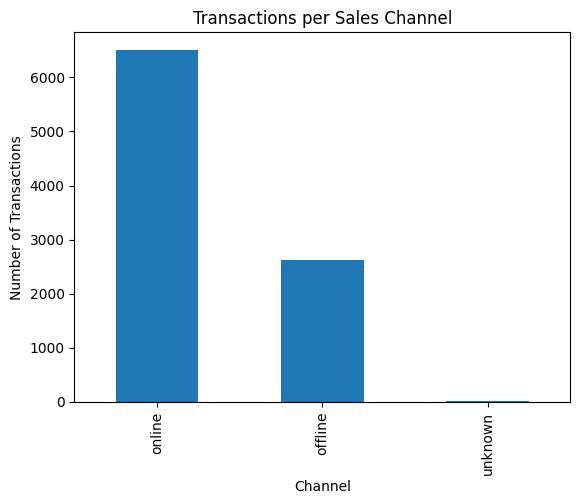

In [597]:
q1.plot(kind='bar')

plt.title('Transactions per Sales Channel')
plt.xlabel('Channel')
plt.ylabel('Number of Transactions')
plt.show()


2- How many transactions involve each product? Count Product_Code occurrences.
- for each productcode how many times does it appear in the dataset



In [598]:
sales['product_code'].value_counts().reset_index(name="transactions")

,product_code,transactions
0,e04,1154
1,f02,989
2,eg02,871
3,e05,793
4,eg03,789
5,p02,783
6,m01,773
7,p01,772
8,e02,765
9,a01,764


3- What is the average (mean) unit price across all products?

In [599]:
avg_price = sales['unit_price_usd'].mean()
print("Average :", avg_price)

Average : 244.23594208981578


4- What is the maximum number of units sold in a single transaction?


In [600]:
sales['units_sold'].max()

10

5- What is the minimum unit price in the dataset?


In [601]:
sales['unit_price'].min()

4.41

6- How many sales transactions had a discount?


In [602]:
discountNum = (sales['discount_%'] > 0).sum()
print("Number of Transaction with discount is :",discountNum,"Transaction")

Number of Transaction with discount is : 126 Transaction


7- How many unique orders are there?


In [603]:
unique_orders = sales['order_id'].nunique()
print("Number of unique orders:", unique_orders)

Number of unique orders: 8481


8- How many customers in each segment?


In [604]:
sales.drop_duplicates(['customer_id','customer_segment'])['customer_segment'].value_counts().reset_index(name='customers')

,customer_segment,customers
0,One-time,500
1,Standard,350
2,Premium,100
3,Loyal,50


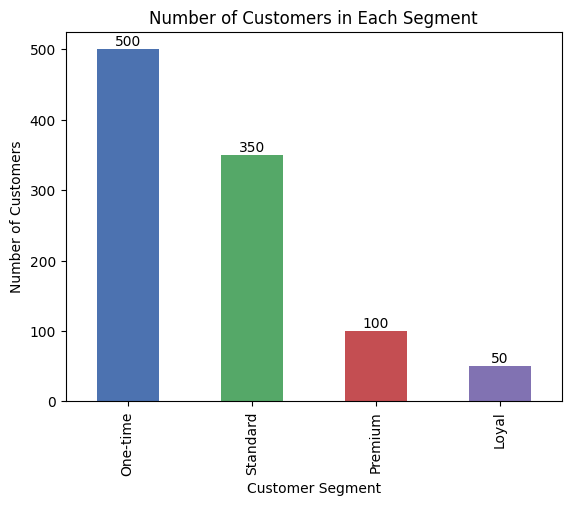

In [605]:
q8 = sales.drop_duplicates(['customer_id','customer_segment'])['customer_segment'].value_counts()

q8.plot(kind='bar', color=['#4C72B0','#55A868','#C44E52','#8172B2'])
plt.title('Number of Customers in Each Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')

for i, v in enumerate(q8):
    plt.text(i, v + 5, str(v), ha='center', fontsize=10)

plt.show()


9- In 2024, which day of the week had the highest sales amount?

In [606]:
q9 = sales[sales['year'] == 2024].groupby('weekday_name')['total_amount'].sum().reset_index().sort_values('total_amount', ascending=False)




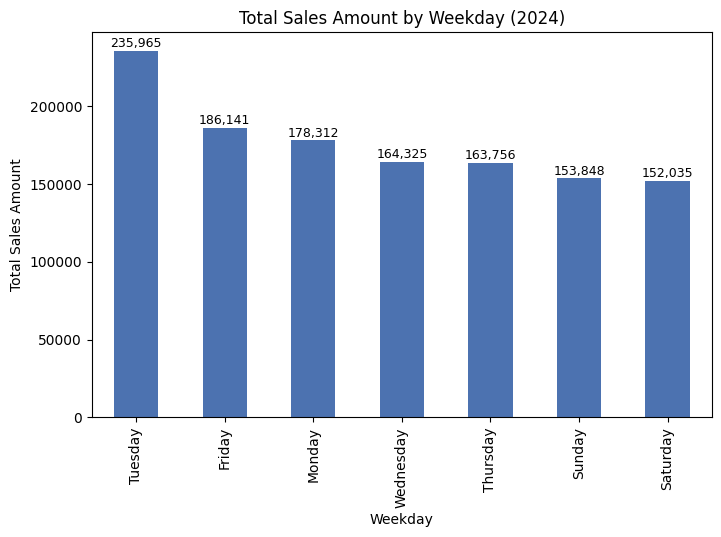

In [607]:
q9 = (
    sales[sales['year'] == 2024]
    .groupby('weekday_name')['total_amount']
    .sum()
    .sort_values(ascending=False)
)

q9.plot(kind='bar', color='#4C72B0', figsize=(8,5))
plt.title('Total Sales Amount by Weekday (2024)')
plt.xlabel('Weekday')
plt.ylabel('Total Sales Amount')

# Add numbers on top of bars
for i, v in enumerate(q9):
    plt.text(i, v + (0.01 * max(q9)), f'{v:,.0f}', ha='center', fontsize=9)

plt.show()


10- Identify all sales in 2024 from Jordan where the sales volume is categorized as 'High' and the products sold were not 'Gaming Chair',
'Keyboard', 'Monitor', 'Tablet', 'Chair'


---



*   How many sales transactions are there?

*   How many sales transactions with ‘Premium’ customer segment?



In [608]:
exclude_products = ['Gaming Chair','Keyboard','Monitor','Tablet','Chair']

mask = (
    (sales['year'] == 2024) &
    (sales['country'] == 'jordan') &
    (sales['sales_volume_category'] == 'High') &
    (~sales['product'].isin(exclude_products))
)

total_tx = sales[mask].shape[0]
premium_tx = sales[mask & (sales['customer_segment'] == 'Premium')].shape[0]


print("Total transactions:", total_tx)
print("Premium customer transactions:", premium_tx)

Total transactions: 190
Premium customer transactions: 64


11- The company is considering closing one of its sales channels in one country due to high operating costs. Using the data, which country and channel combination has the lowest number of transactions, and might be the best candidate for closure?


In [609]:
lowest = sales[['country','channel']].value_counts().reset_index(name='transactions')
lowest = lowest.sort_values('transactions', ascending=True)

lowest.head(3)

,country,channel,transactions
5,jordan,unknown,1
4,lebanon,unknown,4
3,lebanon,offline,466


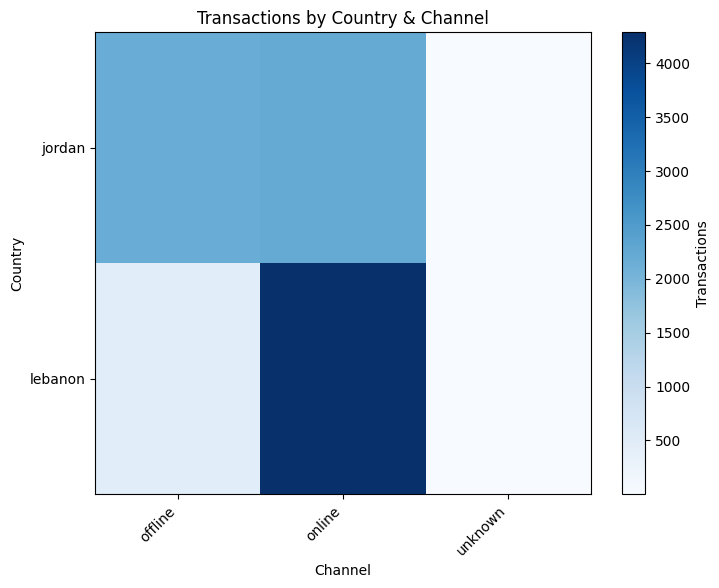

In [610]:
q11 = (
    sales[['country','channel']]
    .value_counts()
    .reset_index(name='transactions')
    .pivot(index='country', columns='channel', values='transactions')
    .fillna(0)
)

plt.figure(figsize=(8,6))
plt.imshow(q11, cmap="Blues", aspect="auto")
plt.colorbar(label="Transactions")
plt.xticks(range(len(q11.columns)), q11.columns, rotation=45, ha='right')
plt.yticks(range(len(q11.index)), q11.index)
plt.title("Transactions by Country & Channel")
plt.xlabel("Channel")
plt.ylabel("Country")
plt.show()


12- Using the customers.csv file,


1.   identify the dominant sector among the loyal customer segment.
2.   Which city has the highest total sales volume (units sold) in Jordan via the online channel? Show the results sorted in descending order of sales volume.




In [611]:
sales['customer_id']


,customer_id
0,custj00001
1,custj00002
2,custj00002
3,custj00002
4,custj00002
...,...
9142,custl00497
9143,custl00498
9144,custl00498
9145,custl00499


In [612]:
customers["customer_id"] = customers["customer_id"].str.strip().str.lower()
customers['customer_id']

,customer_id
0,custj00001
1,custj00002
2,custj00002
3,custj00003
4,custj00004
...,...
1373,custl00497
1374,custl00497
1375,custl00498
1376,custl00499


In [613]:
loyal_sales = sales[sales["customer_segment"] == "Loyal"]
loyal_with_sector = loyal_sales.merge(customers[["customer_id","sector"]],on="customer_id")
dominant_sector = (loyal_with_sector[["customer_id","sector"]].drop_duplicates().value_counts(subset=["sector"]).idxmax())

print("Dominant sector among loyal customers:", dominant_sector)

Dominant sector among loyal customers: ('university',)


In [614]:
###############################################################

In [615]:
customers["city"] = customers["city"].str.strip().str.lower()

In [616]:
jordan_online = sales[(sales["country"] == "jordan") & (sales["channel"] == "online")]
jordan_online = jordan_online.merge(customers[["customer_id","city"]],on="customer_id")
city_sales = (jordan_online.groupby("city")["units_sold"].sum().sort_values(ascending=False).reset_index())

In [617]:
city_sales.head(10)


,city,units_sold
0,amman,6560
1,irbid,3915
2,aqaba,747
3,madaba,626
4,karak,457
5,zarqa,361


13- Which products are most frequently sold together in the same order? List the top product pairs and how many times they occurred together?


In [618]:
tmp = sales[["order_id","product"]].drop_duplicates()

pairs_df = (
    tmp.merge(tmp, on="order_id")
       .query("product_x < product_y")
       .groupby(["product_x","product_y"]).size()
       .reset_index(name="count")
       .sort_values("count", ascending=False)
)

pairs_df

,product_x,product_y,count
2,keyboard,mouse,383
0,chair,laptop,182
1,gaming chair,headset,101


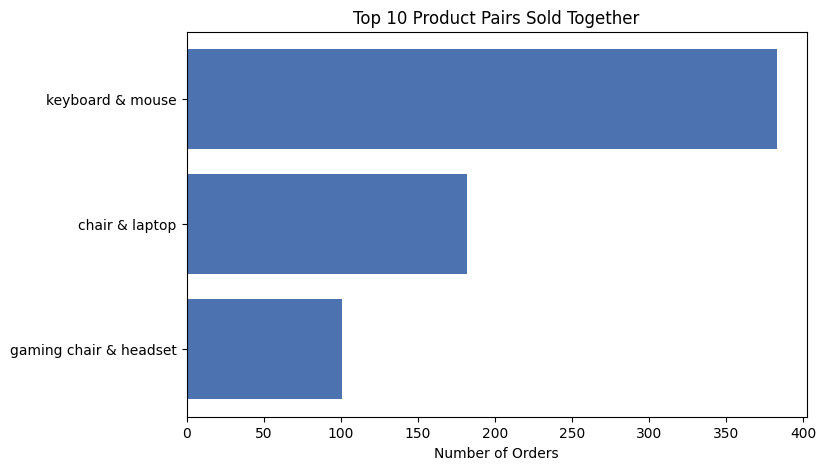

In [619]:
tmp = sales[['order_id','product']].drop_duplicates()
pairs_df = (
    tmp.merge(tmp, on='order_id')
      .query('product_x < product_y')
      .groupby(['product_x','product_y'])
      .size()
      .reset_index(name='count')
      .sort_values('count', ascending=False)
)

top_pairs = pairs_df.head(10)

plt.figure(figsize=(8,5))
plt.barh(
    top_pairs['product_x'] + " & " + top_pairs['product_y'],
    top_pairs['count'],
    color="#4C72B0"
)
plt.title("Top 10 Product Pairs Sold Together")
plt.xlabel("Number of Orders")
plt.gca().invert_yaxis()
plt.show()


14-*Which day of the week shows the highest sales for each product category? Create a heatmap showing sales volume by product and weekday?*


In [620]:
highest_days = (
    sales.groupby(["product", "weekday_name"])["total_amount"]
    .sum()
    .unstack(fill_value=0)
    .idxmax(axis=1)
    .reset_index(name ="day")
)
highest_days


,product,day
0,accessory,Thursday
1,cable,Sunday
2,chair,Saturday
3,gaming chair,Saturday
4,headset,Saturday
5,keyboard,Friday
6,laptop,Tuesday
7,monitor,Tuesday
8,mouse,Sunday
9,phone,Tuesday


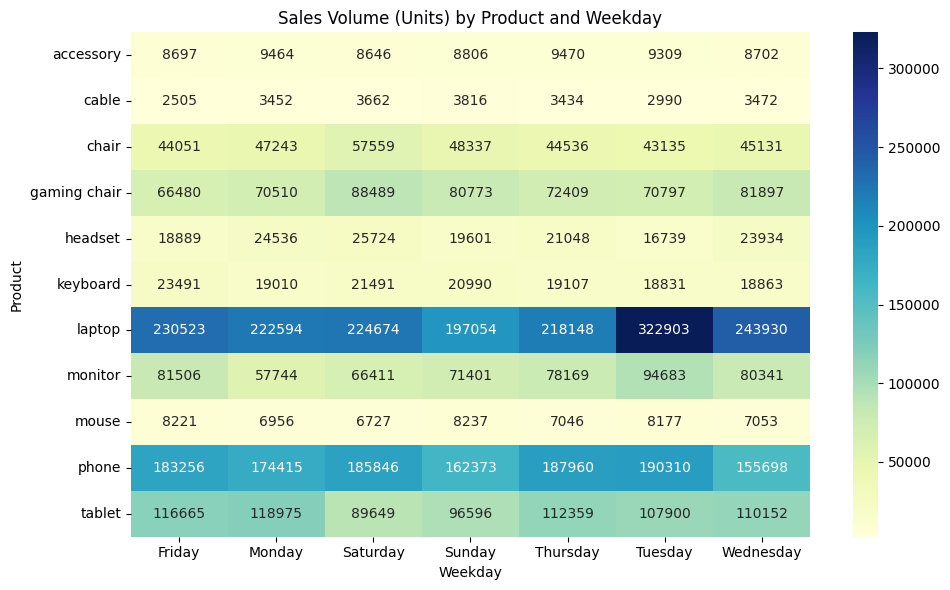

In [621]:
import seaborn as sns
import matplotlib.pyplot as plt

pivot_table = (
    sales.groupby(["product", "weekday_name"])["total_amount"]
    .sum()
    .unstack(fill_value=0)
)

plt.figure(figsize=(10,6))
sns.heatmap(pivot_table, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title("Sales Volume (Units) by Product and Weekday")
plt.xlabel("Weekday")
plt.ylabel("Product")
plt.tight_layout()
plt.show()


15- Compare weekday sales trends for Jordan vs. Lebanon. Which weekdays are most profitable in each country?


In [622]:
result = (
    sales.groupby(["country","weekday_name"])["units_sold"]
         .sum()
         .unstack(fill_value=0)
         .agg(["idxmax","max"], axis=1)
         .rename(columns={"idxmax":"best_weekday","max":"max_units"})
)

result


,best_weekday,max_units
country,,
jordan,Wednesday,1922
lebanon,Saturday,1945


16- Find the top-performing salesperson per year (2022, 2023, 2024) based on total sales amount Show their total sales amount for each year


In [623]:
years = [2022, 2023, 2024]

result = (
    sales[sales["year"].isin(years)]
          .groupby(["year","sales_person"])["total_amount"].sum()
         .reset_index()
         .sort_values(["year","total_amount"], ascending=[True,False])
         .groupby("year").head(1)
)

result


,year,sales_person,total_amount
2,2022,lina,246710.302306
10,2023,sami,274164.966621
12,2024,ahmed,255498.591750


17 Which salesperson generated the highest commission over the period? Who generated the least?


In [624]:
commissions = (sales.groupby("sales_person")["commission_amount"].sum().reset_index())

highest = commissions.loc[commissions["commission_amount"].idxmax()]
lowest  = commissions.loc[commissions["commission_amount"].idxmin()]

print("Highest commission earner:")
highest



Highest commission earner:


,4
sales_person,sami
commission_amount,35276.523011


In [625]:
print("\nLowest commission earner:")
lowest


Lowest commission earner:


,5
sales_person,sara
commission_amount,13573.46683


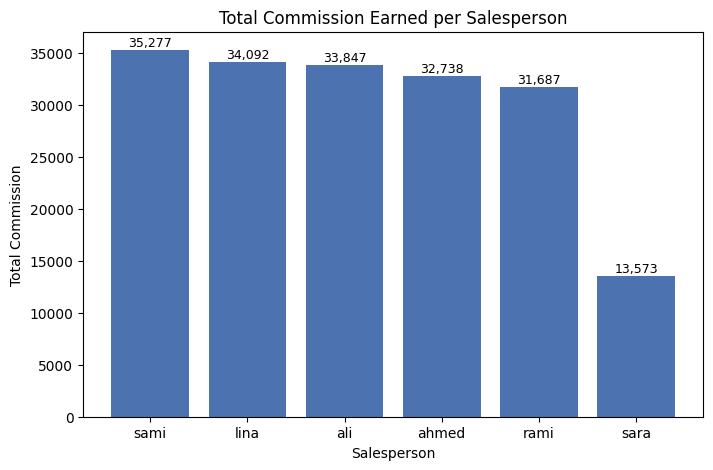

In [626]:
commissions = (
    sales.groupby("sales_person")["commission_amount"]
         .sum()
         .reset_index()
         .sort_values("commission_amount", ascending=False)
)

plt.figure(figsize=(8,5))
plt.bar(commissions["sales_person"], commissions["commission_amount"], color="#4C72B0")
plt.title("Total Commission Earned per Salesperson")
plt.xlabel("Salesperson")
plt.ylabel("Total Commission")

for i, v in enumerate(commissions["commission_amount"]):
    plt.text(i, v + (0.01 * max(commissions["commission_amount"])), f"{v:,.0f}",
             ha='center', fontsize=9)

plt.show()


18- Calculate the Year-over-Year (YoY) percentage change in sales for each country. Visualize the sales trends for all countries over the years. Based on your results, describe how each country is performing. Identify which country shows consistent growth, which is stable, and if any country shows declining trends.


In [627]:
yearly_sales = (
    sales.groupby(["year","country"])["total_amount"]
         .sum()
         .reset_index()
         .sort_values(["country","year"])
)
yearly_sales["yoy_change_%"] = (
    yearly_sales.groupby("country")["total_amount"]
                .pct_change() * 100
).round(2)
yearly_sales





,year,country,total_amount,yoy_change_%
0,2021,jordan,609771.412950,NaN
2,2022,jordan,596604.605940,-2.16
4,2023,jordan,622081.003410,4.27
6,2024,jordan,688462.200240,10.67
8,2025,jordan,346446.239730,-49.68
1,2021,lebanon,544805.646664,NaN
3,2022,lebanon,588068.694531,7.94
5,2023,lebanon,614461.835712,4.49
7,2024,lebanon,545919.738324,-11.15
9,2025,lebanon,318055.676636,-41.74


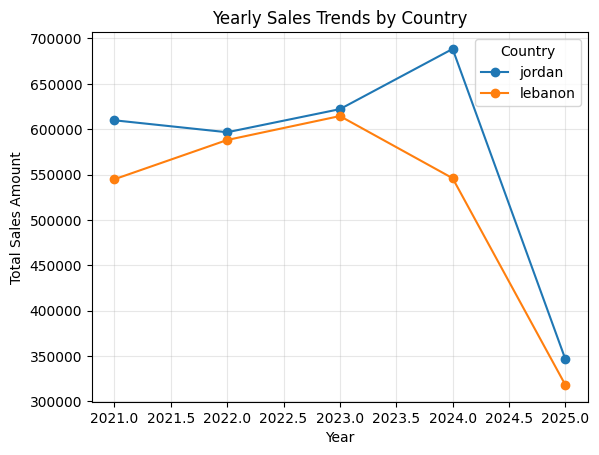

In [628]:
q18p = (
    sales.groupby(['year','country'])['total_amount']
         .sum()
         .reset_index()
)

for country in q17['country'].unique():
    country_data = q17[q17['country'] == country]
    plt.plot(country_data['year'], country_data['total_amount'], marker='o', label=country)

plt.title("Yearly Sales Trends by Country")
plt.xlabel("Year")
plt.ylabel("Total Sales Amount")
plt.legend(title="Country")
plt.grid(True, alpha=0.3)
plt.show()


19- Create a monthly summary report for each product showing total sales revenue, number of transactions, and total units sold.


*   Show the trend of total sales for a specific product over the months of 2024




In [629]:
monthly_summary = (
    sales.groupby(["year","month","product"])
         .agg(
             total_revenue=("total_amount","sum"),
             num_transactions=("order_id","count"),
             total_units=("units_sold","sum")
         )
         .reset_index()
         .sort_values(["year","month","product"])
)

monthly_summary.head()


,year,month,product,total_revenue,num_transactions,total_units
0,2021,1,accessory,771.137400,9,26
1,2021,1,cable,499.961391,18,63
2,2021,1,chair,7885.729300,22,66
3,2021,1,gaming chair,6358.610300,13,29
4,2021,1,headset,3199.197900,17,46


In [630]:
product_name = "laptop"

trend_2024 = (
    monthly_summary[(monthly_summary["year"] == 2024) &
                    (monthly_summary["product"] == product_name)]
)

trend_2024


,year,month,product,total_revenue,num_transactions,total_units
402,2024,1,laptop,12337.980858,7,10
413,2024,2,laptop,40583.045985,12,32
424,2024,3,laptop,24644.877759,8,20
435,2024,4,laptop,32812.129375,13,27
446,2024,5,laptop,43328.009335,19,35
457,2024,6,laptop,35181.363619,16,29
468,2024,7,laptop,42293.540060,16,35
479,2024,8,laptop,26277.812755,11,22
490,2024,9,laptop,31741.125930,13,27
501,2024,10,laptop,26801.983961,11,21


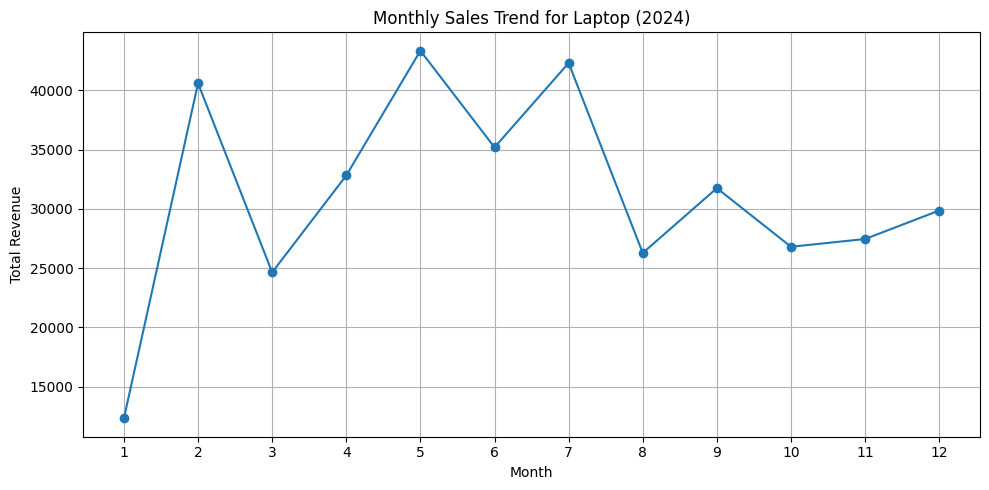

In [631]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(trend_2024["month"], trend_2024["total_revenue"], marker="o")

plt.title(f"Monthly Sales Trend for {product_name.title()} (2024)")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.xticks(range(1,13))
plt.grid(True)
plt.tight_layout()
plt.show()


20- How many promotion periods were there? For each period, specify the month and year, and list the products included in the promotion?


*   Extra : which promotion period increased, decreased, or had no effect on  sales of promotions products
m



In [632]:
promo_data = sales[sales["promotion_flag"] == True]

promotion_summary = (
    promo_data.groupby(["year","month"])["product"]
              .unique()
              .reset_index()
)

num_periods = len(promotion_summary)

print(f"Number of promotion periods: {num_periods}")



Number of promotion periods: 3


In [633]:
promotion_summary

,year,month,product
0,2023,7,"[laptop, mouse, keyboard, chair]"
1,2024,11,"[headset, gaming chair]"
2,2024,12,"[gaming chair, headset]"
